# Spectra v1: 1D Conv Autoencoder for LAMOST CN-Star Detection

**Complete pipeline**: Unsupervised pretraining → Bottleneck feature extraction → PU-Bagging classification → Candidate analysis

**Core Question**: Can AE-compressed features (64-d, 10.9x compression) retain CN band discriminative information
compared to raw 700-pixel spectra?

**Self-contained**: This notebook auto-detects cached checkpoints/features/results.
Missing artifacts are computed on-demand. With full cache, runtime is ~1-2 min.
Training from scratch takes ~30 min on GPU.

**CN Molecular Bands**: CN3839 (3830-3883A), CN4142 (4120-4216A), CH4300 (4285-4315A)**Data**: 33,589 LAMOST spectra (700 px, 3800-4500A), 73 known CN-enhanced positives


In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ═══ Robust project root detection ═══
_NB_DIR = Path().resolve()
_ROOT = _NB_DIR
# If we're inside SpectraAE, go up one level
if _ROOT.name == 'SpectraAE':
    _ROOT = _ROOT.parent
# Verify by checking for key data file
if not (_ROOT / 'ML' / '_cache' / 'X_clean.npy').exists():
    for _candidate in [_NB_DIR.parent, _NB_DIR.parent.parent]:
        if (_candidate / 'ML' / '_cache' / 'X_clean.npy').exists():
            _ROOT = _candidate
            break

if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from SpectraAE.models.autoencoder import ConvAutoencoder, Encoder, Decoder
from SpectraAE.extract_features import extract_features
from SpectraAE.pretrain import pretrain_autoencoder
from ML.pu_bagging import load_pu_data, run_pu_bagging, build_comparison_df
from ML.utils import FEATURE_COLS_CN9, compute_cluster_zscore
from ML.utils import plot_candidate_spectra, plot_teff_logg_distribution

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root: {_ROOT}')
print(f'Device: {DEVICE}')
print(f'Imports OK')


Project root: D:\资料\2026大创\Lamost
Device: cuda
Imports OK


## 1. Data Loading

Loading preprocessed 33,589 LAMOST spectra from `ML/_cache`.
Each spectrum: 700 pixels (3800-4500A, step 1A), continuum-normalized to flux~1.0.

**73 known CN-enhanced positives** (from CNstar.csv + FT_cands.csv), rest 33,516 unlabeled.

Train/val/test split is fixed via `load_pu_data()` for reproducibility.


In [2]:
CACHE_DIR = _ROOT / 'ML' / '_cache'
X_clean = np.load(CACHE_DIR / 'X_clean.npy').astype(np.float32)
stars_clean = pd.read_pickle(CACHE_DIR / 'stars_clustered.pkl')
wave = np.arange(3800.0, 4500.0, 1.0)

data_pu = load_pu_data()
y_all = data_pu['y_all']
cluster_ids = data_pu['cluster_ids']
df_model = data_pu['df_model']
pos_mask = y_all == 1
n_pos = int(y_all.sum())

print(f'Spectra shape: {X_clean.shape}')
print(f'Pixel range: [{X_clean.min():.4f}, {X_clean.max():.4f}]')
print(f'Global stats: mean={X_clean.mean():.4f}, std={X_clean.std():.4f}')
print(f'Labels: {len(y_all):,} stars, {n_pos} known CN + {int((~pos_mask).sum()):,} unlabeled')
print(f'Train: {len(data_pu["tr_idx"]):,} (pos={int(y_all[data_pu["tr_idx"]].sum())})')
print(f'Test:  {len(data_pu["test_idx"]):,} (pos={int(y_all[data_pu["test_idx"]].sum())})')


Spectra shape: (33589, 700)
Pixel range: [-58.4811, 20.7802]
Global stats: mean=1.0444, std=0.2370
Labels: 33,589 stars, 73 known CN + 33,516 unlabeled
Train: 23,411 (pos=51)
Test:  5,039 (pos=11)


### 1.1 Spectrum Preview: CN Stars vs Normal Stars

The three CN/CH bands are highlighted. CN-enhanced stars show deeper absorption in these regions
(visible as positive difference in the right panel).


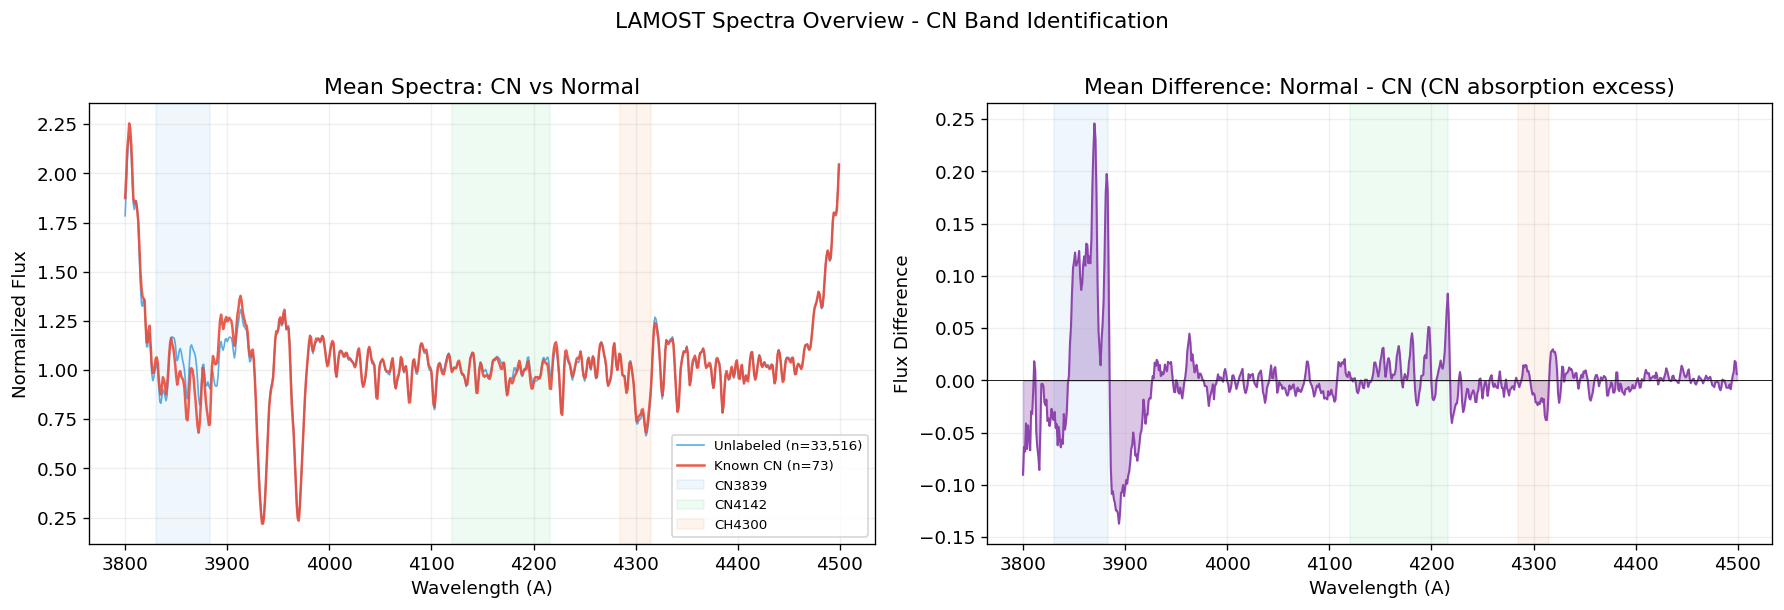

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Mean spectra comparison
ax = axes[0]
ax.plot(wave, X_clean[~pos_mask].mean(axis=0), alpha=0.8, lw=1,
        color='#3498db', label=f'Unlabeled (n={(~pos_mask).sum():,})')
ax.plot(wave, X_clean[pos_mask].mean(axis=0), alpha=0.9, lw=1.5,
        color='#e74c3c', label=f'Known CN (n={n_pos})')
for band, (x1, x2), color in [
    ('CN3839', (3830, 3883), '#3498db'),
    ('CN4142', (4120, 4216), '#2ecc71'),
    ('CH4300', (4285, 4315), '#e67e22'),
]:
    ax.axvspan(x1, x2, alpha=0.08, color=color, label=band)
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Mean Spectra: CN vs Normal')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2)

# Right: Mean difference (absorption excess)
ax = axes[1]
diff = X_clean[~pos_mask].mean(axis=0) - X_clean[pos_mask].mean(axis=0)
ax.plot(wave, diff, lw=1.2, color='#8e44ad')
ax.fill_between(wave, 0, diff, alpha=0.3, color='#8e44ad')
for x1, x2, color in [(3830, 3883, '#3498db'), (4120, 4216, '#2ecc71'), (4285, 4315, '#e67e22')]:
    ax.axvspan(x1, x2, alpha=0.08, color=color)
ax.axhline(y=0, color='black', lw=0.5)
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Flux Difference')
ax.set_title('Mean Difference: Normal - CN (CN absorption excess)')
ax.grid(alpha=0.2)

fig.suptitle('LAMOST Spectra Overview - CN Band Identification', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2. Autoencoder Model Architecture

**Encoder**: 3-layer 1D Conv (stride=2) downsampling + AdaptiveAvgPool + FC → 64-d bottleneck
**Decoder**: FC + 4-stage linear interpolation upsampling + 1D Conv → 700px reconstruction

AE-64d: 700 → 64 (10.9x compression, ~87K params)AE-256d: 700 → 256 (2.7x compression, ~337K params) — optional comparison


In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print('=' * 70)
print(f'{"Model":12s} | {"Config":20s} | {"Params":>10s} | Compression')
print('=' * 70)

ae64_model = ConvAutoencoder(in_channels=1, base_ch=32, latent_dim=64)
print(f'{"AE-64d":12s} | base_ch=32 latent= 64 | {count_params(ae64_model):>10,} | 700→64 (10.9x)')

ae256_model = ConvAutoencoder(in_channels=1, base_ch=64, latent_dim=256)
print(f'{"AE-256d":12s} | base_ch=64 latent=256 | {count_params(ae256_model):>10,} | 700→256 (2.7x)')
print('=' * 70)

# Shape trace through encoder
print('\nEncoder shape progression (AE-64d):')
x_dummy = torch.randn(1, 1, 700)
enc = ae64_model.encoder
shapes = [('Input', tuple(x_dummy.shape))]
x = enc.pad(x_dummy)
shapes.append(('ReflectionPad(2)', tuple(x.shape)))
for name in ['conv1', 'conv2', 'conv3']:
    x = getattr(enc, name)(x)
    shapes.append((f'{name} (stride=2)', tuple(x.shape)))
x = enc.pool(x)
shapes.append(('AdaptiveAvgPool1d', tuple(x.shape)))
x = x.flatten(1)
shapes.append(('Flatten', tuple(x.shape)))
z = enc.fc(x)
shapes.append(('FC → Latent z (64d)', tuple(z.shape)))
for label, s in shapes:
    print(f'  {label:26s} {str(s):18s}')

# Verify reconstruction
x_recon, z_out = ae64_model(x_dummy)
print(f'\nReconstruction shape: {tuple(x_recon.shape)}')
print(f'MSE (random init): {nn.MSELoss()(x_recon, x_dummy).item():.4f}')


Model        | Config               |     Params | Compression
AE-64d       | base_ch=32 latent= 64 |     87,296 | 700→64 (10.9x)
AE-256d      | base_ch=64 latent=256 |    412,288 | 700→256 (2.7x)

Encoder shape progression (AE-64d):
  Input                      (1, 1, 700)       
  ReflectionPad(2)           (1, 1, 704)       
  conv1 (stride=2)           (1, 32, 352)      
  conv2 (stride=2)           (1, 64, 176)      
  conv3 (stride=2)           (1, 128, 88)      
  AdaptiveAvgPool1d          (1, 128, 1)       
  Flatten                    (1, 128)          
  FC → Latent z (64d)        (1, 64)           

Reconstruction shape: (1, 1, 700)
MSE (random init): 1.0979


## 3. Load or Train Autoencoder

Load the pre-trained AE-64d checkpoint. If none exists, train from scratch using `pretrain_autoencoder()`.

**Training config**: AdamW (lr=1e-3, wd=1e-5), CosineAnnealingLR, batch=256, patience=30, max 200 epochs.
Preprocessing: global p1-p99 clipping + scalar standardization.


In [5]:
CHECKPOINT_DIR = _ROOT / 'SpectraAE' / 'checkpoints'
CKPT_PATH = CHECKPOINT_DIR / 'ae_best.pt'
CACHE_DIR_AE = _ROOT / 'SpectraAE' / '_cache'

def load_ae_checkpoint(ckpt_path, latent_dim=64, base_ch=32):
    """Load a trained AE checkpoint and return (model, info_dict)."""
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = ConvAutoencoder(in_channels=1, base_ch=base_ch, latent_dim=latent_dim).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    info = {
        'epoch': ckpt['epoch'], 'val_loss': ckpt['val_loss'],
        'scaler_mean': ckpt['scaler_mean'], 'scaler_std': ckpt['scaler_std'],
        'params': sum(p.numel() for p in model.parameters()),
    }
    return model, info

# ── AE-64d (primary) ──
if CKPT_PATH.exists():
    print(f'Loading checkpoint: {CKPT_PATH}')
    model, ae_info = load_ae_checkpoint(CKPT_PATH, latent_dim=64, base_ch=32)
    print(f'  Epoch={ae_info["epoch"]}  val_loss={ae_info["val_loss"]:.6f}  params={ae_info["params"]:,}')
else:
    print('No checkpoint found. Training AE-64d from scratch...')
    print('(Expected: 10-30 min on GPU, longer on CPU)')
    model, history = pretrain_autoencoder(
        X_clean, latent_dim=64, base_ch=32, n_epochs=200,
        batch_size=256, lr=1e-3, patience=30, device=DEVICE,
        checkpoint_dir=str(CHECKPOINT_DIR), verbose=True,
    )
    ae_info = {
        'epoch': history['best_epoch'], 'val_loss': history['best_val_loss'],
        'scaler_mean': history['scaler_mean'], 'scaler_std': history['scaler_std'],
        'params': sum(p.numel() for p in model.parameters()),
    }
    print(f'Training complete: epoch={ae_info["epoch"]}  val_loss={ae_info["val_loss"]:.6f}')

print(f'\nScaler: mean={ae_info["scaler_mean"]:.4f}  std={ae_info["scaler_std"]:.4f}')

# ── AE-256d (optional) ──
CKPT256_PATH = CHECKPOINT_DIR / 'ae256' / 'ae_best.pt'
has_256 = CKPT256_PATH.exists()
if has_256:
    model256, ae256_info = load_ae_checkpoint(CKPT256_PATH, latent_dim=256, base_ch=64)
    print(f'AE-256d available: epoch={ae256_info["epoch"]}  val_loss={ae256_info["val_loss"]:.6f}')
else:
    print(f'AE-256d not found at {CKPT256_PATH} — comparison will use AE-64d only.')


Loading checkpoint: D:\资料\2026大创\Lamost\SpectraAE\checkpoints\ae_best.pt
  Epoch=199  val_loss=0.448669  params=87,296

Scaler: mean=1.0435  std=0.2244
AE-256d available: epoch=297  val_loss=0.447041


### 3.1 Reconstruction Quality — Random Samples

Reconstruct 8 randomly selected spectra with the trained AE-64d.
The AE learns to reproduce the overall continuum shape but may miss fine absorption features.


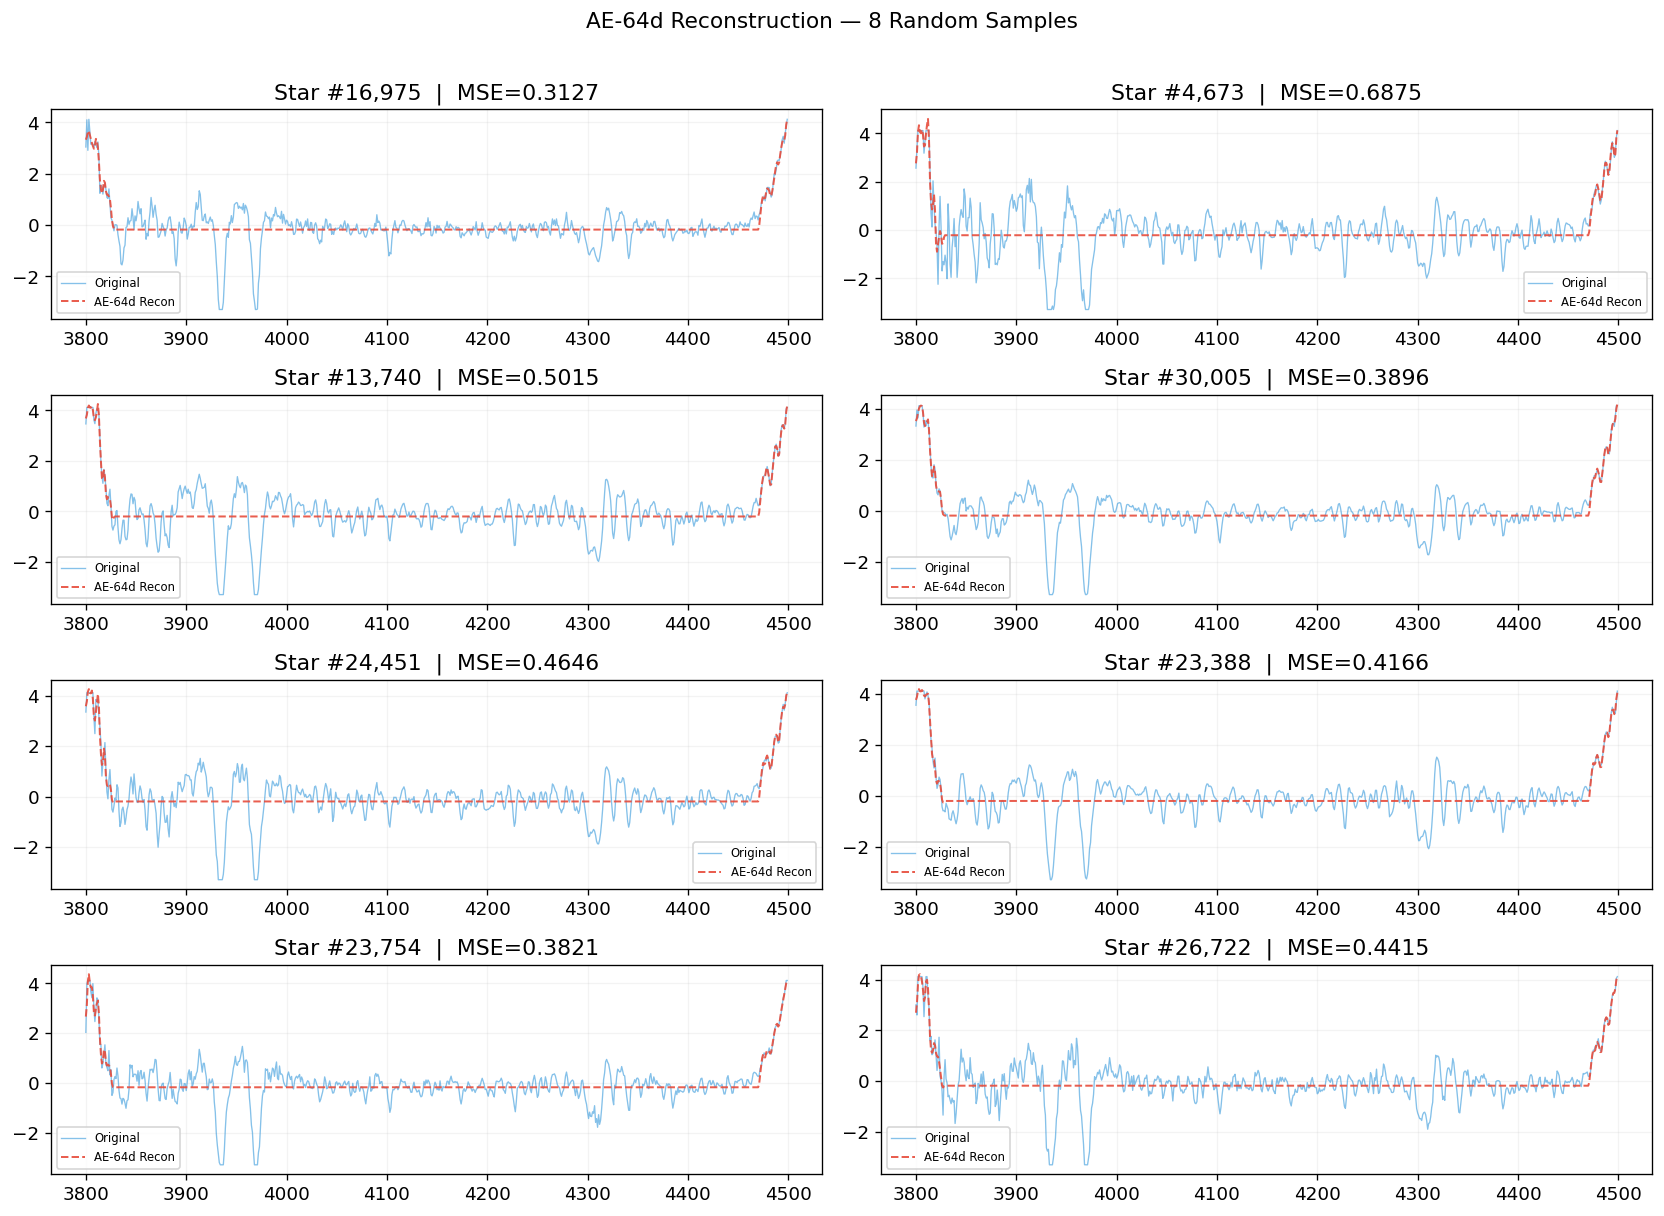

Global reconstruction MSE (5K sample): 0.447415


In [6]:
def prepare_for_ae(X, scaler_mean, scaler_std):
    lo = float(np.percentile(X, 1))
    hi = float(np.percentile(X, 99))
    return (np.clip(X, lo, hi) - scaler_mean) / scaler_std

def reconstruct_batch(model, X, sm, ss):
    X_norm = prepare_for_ae(X, sm, ss)
    X_t = torch.from_numpy(X_norm).unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        recon_t, _ = model(X_t)
    return recon_t.cpu().numpy()[:, 0, :], X_norm

rng = np.random.RandomState(42)
n_show = 8
sample_idx = rng.choice(len(X_clean), n_show, replace=False)
X_sample = X_clean[sample_idx]

recon64, X_norm64 = reconstruct_batch(model, X_sample,
                                       ae_info['scaler_mean'], ae_info['scaler_std'])

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    ax.plot(wave, X_norm64[i], alpha=0.6, lw=0.8, color='#3498db', label='Original')
    ax.plot(wave, recon64[i], alpha=0.9, lw=1.2, color='#e74c3c', ls='--', label='AE-64d Recon')
    mse = np.mean((X_norm64[i] - recon64[i]) ** 2)
    ax.set_title(f'Star #{sample_idx[i]:,}  |  MSE={mse:.4f}')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

fig.suptitle('AE-64d Reconstruction — 8 Random Samples', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Global MSE estimate
N_EVAL = 5000
idx_eval = rng.choice(len(X_clean), N_EVAL, replace=False)
recon_eval, X_eval_norm = reconstruct_batch(model, X_clean[idx_eval],
                                             ae_info['scaler_mean'], ae_info['scaler_std'])
global_mse = np.mean((X_eval_norm - recon_eval) ** 2)
print(f'Global reconstruction MSE (5K sample): {global_mse:.6f}')


### 3.2 Per-Pixel Reconstruction Error — CN Band Focus

MSE per wavelength pixel. The CN band regions are the critical signal.
If the AE discards CN information, these regions should show higher relative error.


AE-64d Global MSE: 0.449355
  CN3839       (px[30:83]): 0.401236
  CN4142       (px[320:416]): 0.077579
  CH4300       (px[485:515]): 0.790536
  Continuum    (px[400:480]): 0.142438


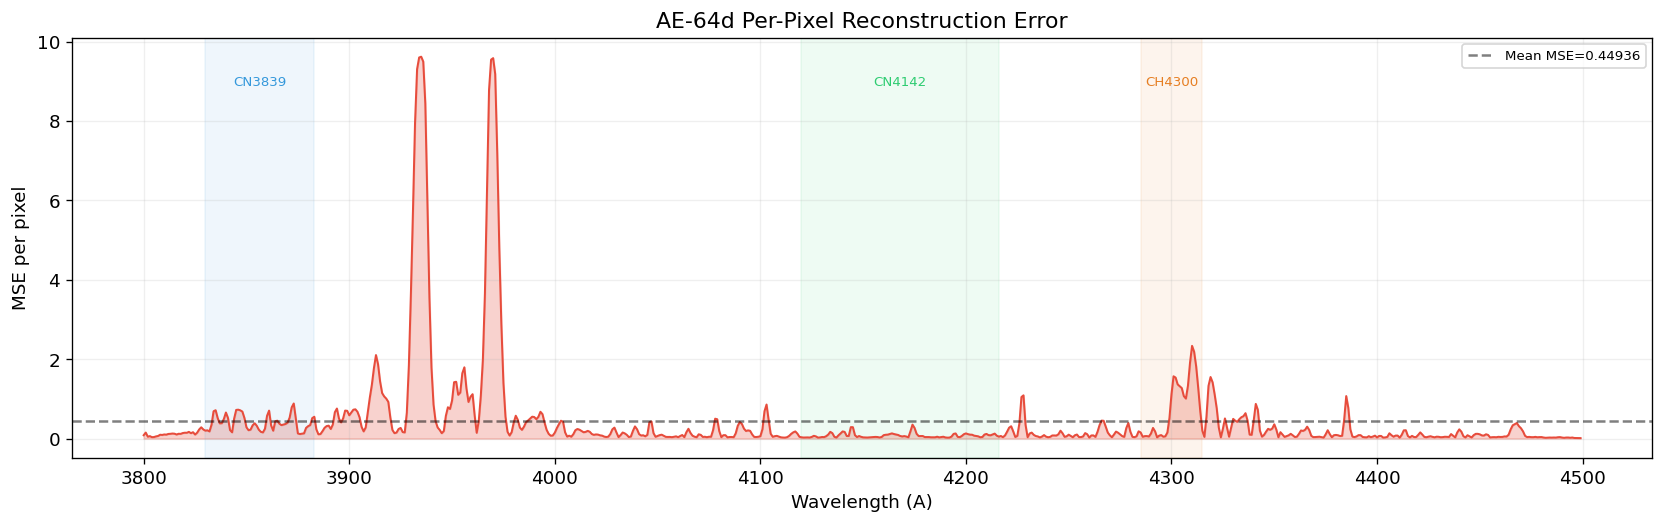

In [7]:
def compute_per_pixel_mse(model, X, sm, ss, n_sample=5000):
    idx = np.random.RandomState(42).choice(len(X), min(n_sample, len(X)), replace=False)
    recon, X_norm = reconstruct_batch(model, X[idx], sm, ss)
    return np.mean((X_norm - recon) ** 2, axis=0)

pixel_mse = compute_per_pixel_mse(model, X_clean, ae_info['scaler_mean'], ae_info['scaler_std'])

# Print per-band MSE
bands = [
    ('CN3839', 30, 83),
    ('CN4142', 320, 416),
    ('CH4300', 485, 515),
    ('Continuum', 400, 480),
]
print(f'AE-64d Global MSE: {np.mean(pixel_mse):.6f}')
for name, p1, p2 in bands:
    print(f'  {name:12s} (px[{p1}:{p2}]): {np.mean(pixel_mse[p1:p2]):.6f}')

# Plot
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(wave, pixel_mse, lw=1.2, color='#e74c3c')
ax.fill_between(wave, 0, pixel_mse, alpha=0.25, color='#e74c3c')

y_max = np.percentile(pixel_mse, 99) * 1.1
for band_name, p1, p2, color in [
    ('CN3839', 30, 83, '#3498db'),
    ('CN4142', 320, 416, '#2ecc71'),
    ('CH4300', 485, 515, '#e67e22'),
]:
    x1, x2 = 3800 + p1, 3800 + p2
    ax.axvspan(x1, x2, alpha=0.08, color=color)
    ax.text((x1 + x2) / 2, y_max * 0.92, band_name, ha='center', fontsize=8, color=color)

ax.axhline(y=np.mean(pixel_mse), color='black', ls='--', alpha=0.5,
           label=f'Mean MSE={np.mean(pixel_mse):.5f}')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('MSE per pixel')
ax.set_title('AE-64d Per-Pixel Reconstruction Error')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Bottleneck Feature Extraction

Use the trained encoder to compress all 33,589 spectra into 64-d bottleneck vectors.
These serve as input features for downstream PU-Bagging classification.


In [8]:
FEATS_PATH = CACHE_DIR_AE / 'ae_features_64d.npy'

if FEATS_PATH.exists():
    ae_features = np.load(FEATS_PATH).astype(np.float32)
    print(f'Loaded cached AE features: {ae_features.shape}')
else:
    print('Extracting bottleneck features for all 33,589 spectra...')
    ae_features = extract_features(
        model, X_clean,
        scaler_mean=ae_info['scaler_mean'], scaler_std=ae_info['scaler_std'],
        device=DEVICE,
    )
    CACHE_DIR_AE.mkdir(parents=True, exist_ok=True)
    np.save(FEATS_PATH, ae_features)
    print(f'Saved to {FEATS_PATH}')

print(f'AE features: mean={ae_features.mean():.4f}, std={ae_features.std():.4f}')
fvar = ae_features.var(axis=0)
n_dead = int((fvar < 1e-8).sum())
print(f'Feature-wise variance: min={fvar.min():.6f}, max={fvar.max():.6f}, '
      f'dead dims={n_dead}/{len(fvar)}')


Loaded cached AE features: (33589, 64)
AE features: mean=0.0143, std=0.0501
Feature-wise variance: min=0.000032, max=0.000229, dead dims=0/64


### 4.1 Latent Space PCA Visualization

Project 64-d bottleneck features to 2D via PCA. Color by Teff to check if the latent space
preserves physically meaningful structure. Known CN stars marked with stars.


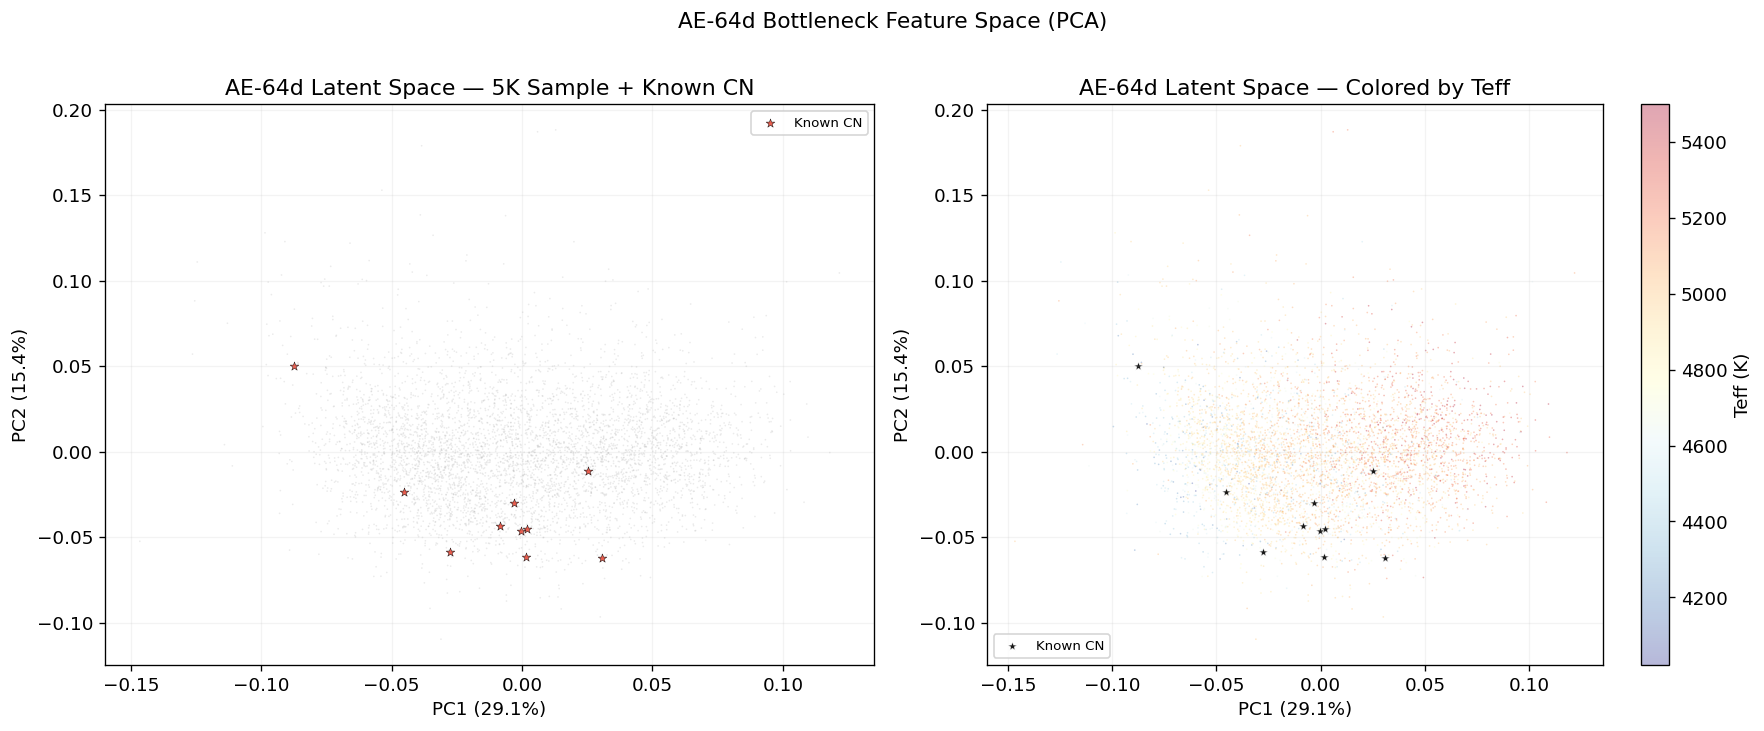

PCA explained variance: PC1=0.291, PC2=0.154, cumulative=0.446


In [9]:
pca = PCA(n_components=2)
z_pca = pca.fit_transform(ae_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Known CN highlighted
ax = axes[0]
bg = np.random.RandomState(42).choice(len(z_pca), min(5000, len(z_pca)), replace=False)
ax.scatter(z_pca[bg, 0], z_pca[bg, 1], s=1, alpha=0.25, c='#b0b0b0', ec='none')
pos_bg = bg[np.isin(bg, np.where(pos_mask)[0])]
if len(pos_bg) > 0:
    ax.scatter(z_pca[pos_bg, 0], z_pca[pos_bg, 1], s=30, alpha=0.9,
               c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('AE-64d Latent Space — 5K Sample + Known CN')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Right: Colored by Teff
ax = axes[1]
teff_bg = df_model.iloc[bg]['teff'].values
sc = ax.scatter(z_pca[bg, 0], z_pca[bg, 1], s=1, alpha=0.35, c=teff_bg,
                cmap='RdYlBu_r', ec='none')
if len(pos_bg) > 0:
    ax.scatter(z_pca[pos_bg, 0], z_pca[pos_bg, 1], s=30, alpha=0.9,
               c='black', ec='white', lw=0.3, marker='*', label='Known CN')
plt.colorbar(sc, ax=ax, label='Teff (K)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('AE-64d Latent Space — Colored by Teff')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.15)

fig.suptitle('AE-64d Bottleneck Feature Space (PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca.explained_variance_ratio_[1]:.3f}, '
      f'cumulative={sum(pca.explained_variance_ratio_[:2]):.3f}')


### 4.2 Latent Dimension Analysis

Examine individual bottleneck dimensions: which ones carry the most variance?
Compare distributions between CN and unlabeled stars.


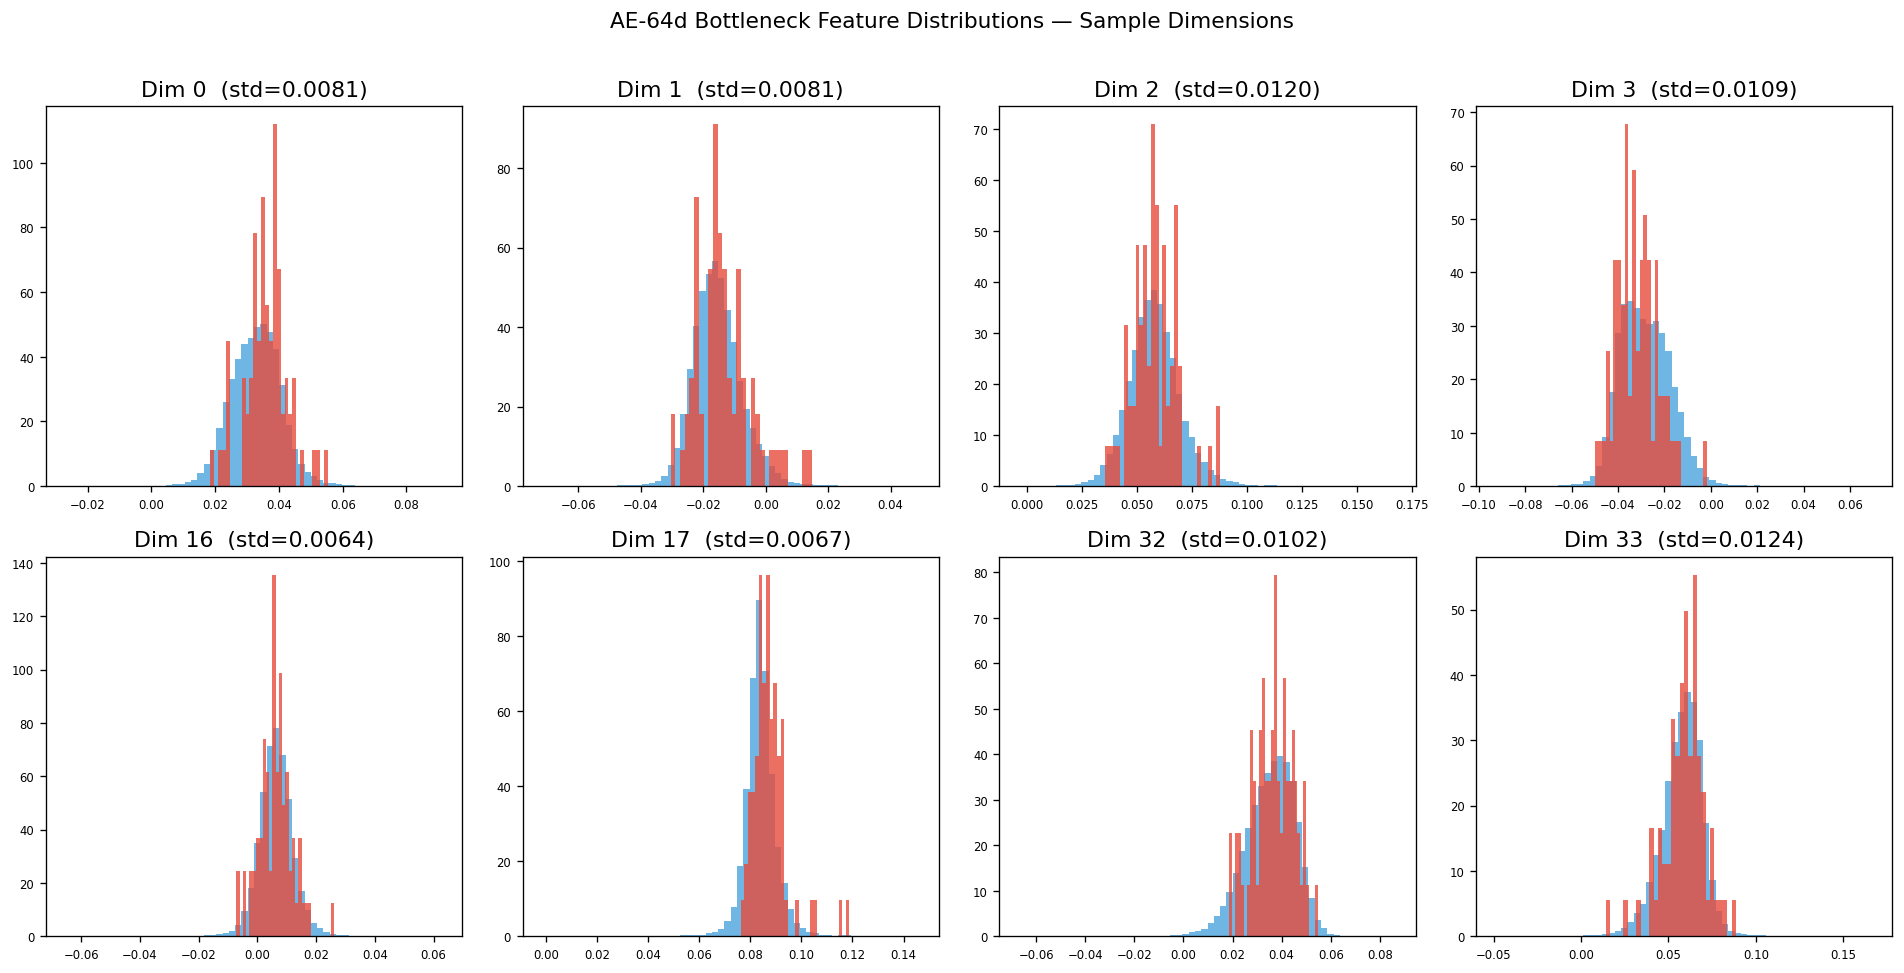

Top 10 highest-variance latent dimensions:
  # 1 dim   5: std=0.0151  CN_mean=-0.014  unl_mean=-0.013  |diff|=0.0016
  # 2 dim  23: std=0.0140  CN_mean=+0.020  unl_mean=+0.014  |diff|=0.0056
  # 3 dim  52: std=0.0133  CN_mean=+0.036  unl_mean=+0.037  |diff|=0.0018
  # 4 dim   9: std=0.0128  CN_mean=-0.078  unl_mean=-0.074  |diff|=0.0035
  # 5 dim  18: std=0.0125  CN_mean=+0.016  unl_mean=+0.015  |diff|=0.0019
  # 6 dim  33: std=0.0124  CN_mean=+0.059  unl_mean=+0.058  |diff|=0.0011
  # 7 dim  28: std=0.0123  CN_mean=-0.005  unl_mean=-0.007  |diff|=0.0016
  # 8 dim   4: std=0.0121  CN_mean=-0.071  unl_mean=-0.071  |diff|=0.0001
  # 9 dim  54: std=0.0121  CN_mean=-0.019  unl_mean=-0.017  |diff|=0.0021
  #10 dim   2: std=0.0120  CN_mean=+0.058  unl_mean=+0.058  |diff|=0.0001


In [10]:
feature_std = ae_features.std(axis=0)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
latent_dims = [0, 1, 2, 3, 16, 17, 32, 33]

for ax, dim in zip(axes.flat, latent_dims):
    ax.hist(ae_features[~pos_mask, dim], bins=60, alpha=0.7, density=True, color='#3498db')
    ax.hist(ae_features[pos_mask, dim], bins=30, alpha=0.8, density=True, color='#e74c3c')
    ax.set_title(f'Dim {dim}  (std={feature_std[dim]:.4f})')
    ax.tick_params(labelsize=7)

fig.suptitle('AE-64d Bottleneck Feature Distributions — Sample Dimensions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top 10 highest-variance latent dimensions:')
top_dims = np.argsort(feature_std)[::-1][:10]
for rank, d in enumerate(top_dims, 1):
    # Compute separation between CN and unlabeled in this dim
    cn_mean = ae_features[pos_mask, d].mean()
    unl_mean = ae_features[~pos_mask, d].mean()
    sep = abs(cn_mean - unl_mean)
    print(f'  #{rank:2d} dim {d:3d}: std={feature_std[d]:.4f}  '
          f'CN_mean={cn_mean:+.3f}  unl_mean={unl_mean:+.3f}  |diff|={sep:.4f}')


## 5. PU-Bagging Classification

Run XGBoost PU-Bagging (T=500 iterations) on AE-64d features vs Raw 700px spectra.

**PU-Bagging algorithm**:
1. Randomly sample |P| unlabeled stars as pseudo-negatives
2. Train weak XGBoost (depth=3, 50 trees)
3. Predict all unlabeled stars
4. Repeat T=500 times, average probabilities

**Metrics**: PR-AUC (primary, handles extreme imbalance), ROC-AUC, P@100,
Within-cluster Spearman r (physical consistency), |r_teff| z (Teff bias)


In [11]:
X_ae = StandardScaler().fit_transform(ae_features.astype(np.float32)).astype(np.float32)

RESULTS_DIR = _ROOT / 'SpectraAE' / 'results'
COMP_PATH = RESULTS_DIR / 'pu_bagging_ae_comparison.csv'
PROBS_PATH = RESULTS_DIR / 'ae_pu_probs.csv'

T = 500

if COMP_PATH.exists():
    print('Loading cached PU-Bagging results...')
    comp_df = pd.read_csv(COMP_PATH)
    probs_df = pd.read_csv(PROBS_PATH)
else:
    print(f'Running PU-Bagging (T={T}) — this takes ~5 min...\n')

    # AE-64d
    print(f'{"=" * 60}')
    print(f'PU-Bagging: AE-64d (T={T})')
    print(f'{"=" * 60}')
    res_ae = run_pu_bagging(
        X_ae, y_all, data_pu['tr_idx'], data_pu['test_idx'],
        cluster_ids, df_model, T=T, name='AE-64d')

    # Raw Spectra
    print(f'\n{"=" * 60}')
    print(f'PU-Bagging: Raw Spectra 700-D (T={T})')
    print(f'{"=" * 60}')
    res_spec = run_pu_bagging(
        data_pu['X_spec'], y_all, data_pu['tr_idx'], data_pu['test_idx'],
        cluster_ids, df_model, T=T, name='Raw Spectra 700-D')

    # Build comparison
    comp_df = build_comparison_df(res_ae, res_spec)

    # Save
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    comp_df.to_csv(COMP_PATH, index=False)

    # Per-star probabilities
    probs_df = df_model[['teff', 'logg', 'feh', 'label']].copy()
    probs_df['ae64_prob'] = res_ae['probs_all']
    probs_df['ae64_std'] = res_ae['probs_all_std']
    probs_df['spec_prob'] = res_spec['probs_all']
    probs_df['spec_std'] = res_spec['probs_all_std']
    probs_df.to_csv(PROBS_PATH, index=False)
    print(f'\nSaved to {RESULTS_DIR}')

# Store for downstream use
ae_probs = probs_df['ae64_prob'].values
spec_probs = probs_df['spec_prob'].values
ae_stds = probs_df['ae64_std'].values
spec_stds = probs_df['spec_std'].values

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 260)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(f'\n{"=" * 70}')
print('RESULTS: AE-64d vs Raw Spectra 700-D')
print(f'{"=" * 70}')
print(comp_df.to_string(index=False))


Loading cached PU-Bagging results...

RESULTS: AE-64d vs Raw Spectra 700-D
      Feature Set  Dim   T    ROC     PR   P@50  P@100  |r_teff| raw  |r_teff| z  Mean bias raw  Mean bias z  Within-r  Stability     Time
           AE-64d   64 500 0.9183 0.1671 0.0600 0.0400        0.0254      0.0069         0.0629       0.0063    0.2363     0.1621  38.2103
Raw Spectra 700-D  700 500 0.9974 0.8480 0.2000 0.1000        0.1212      0.0431         0.0790       0.0705    0.2437     0.1372 270.5781


### 5.1 Key Metrics Comparison


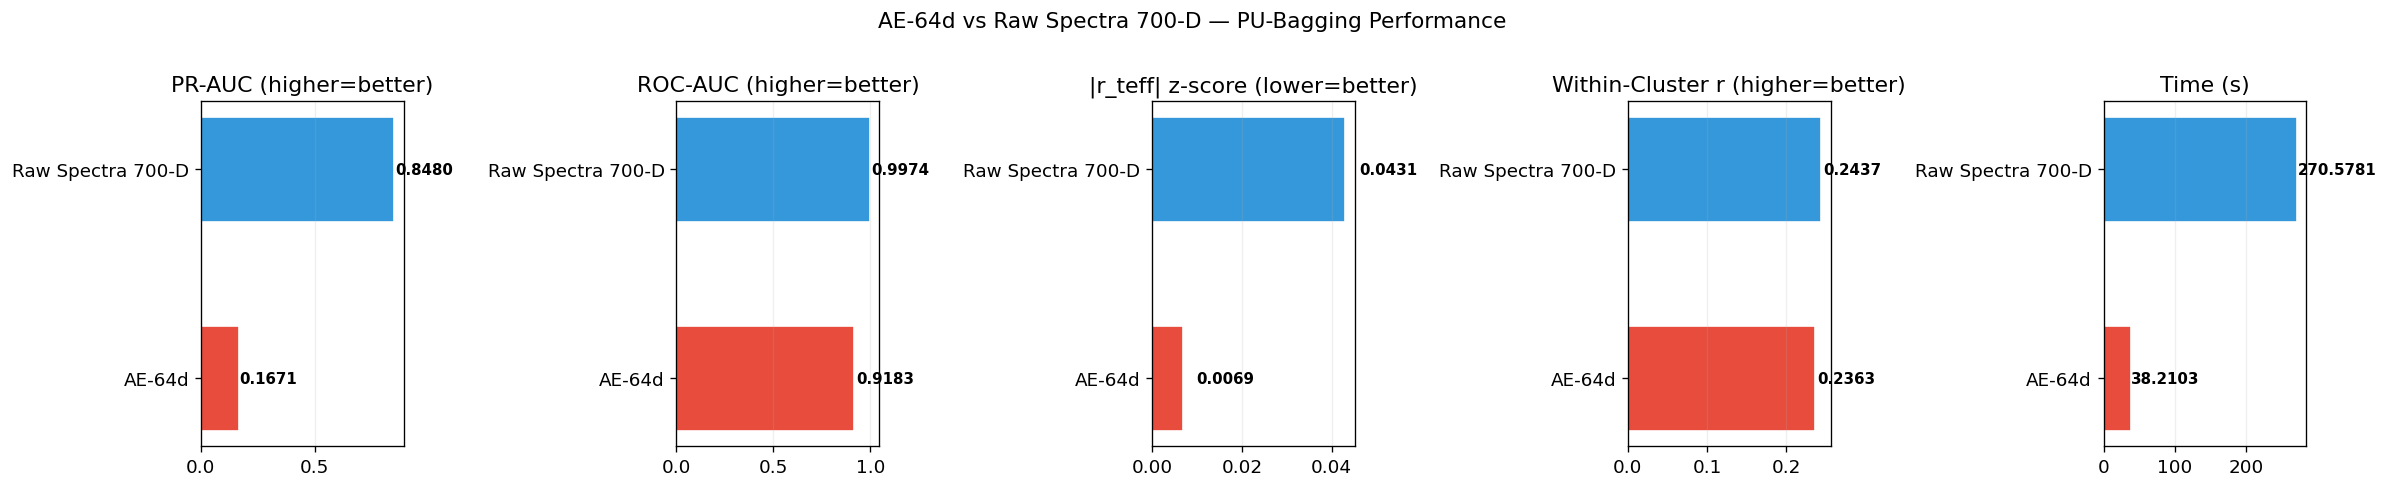

In [12]:
methods = comp_df['Feature Set'].values
metrics = ['PR', 'ROC', '|r_teff| z', 'Within-r', 'Time']
titles = ['PR-AUC (higher=better)', 'ROC-AUC (higher=better)',
          '|r_teff| z-score (lower=better)', 'Within-Cluster r (higher=better)',
          'Time (s)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors_bar = ['#e74c3c', '#3498db']

for ax, metric, title in zip(axes, metrics, titles):
    vals = comp_df[metric].values
    bars = ax.barh(methods, vals, color=colors_bar, ec='white', height=0.5)
    for bar, val in zip(bars, vals):
        offset = max(val * 0.008, 0.003)
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('AE-64d vs Raw Spectra 700-D — PU-Bagging Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Probability Distribution Analysis

How do AE-64d and Raw Spectra assign probabilities to known CN stars vs unlabeled stars?
Ideal: known CN stars cluster at high probability, clean separation from unlabeled.


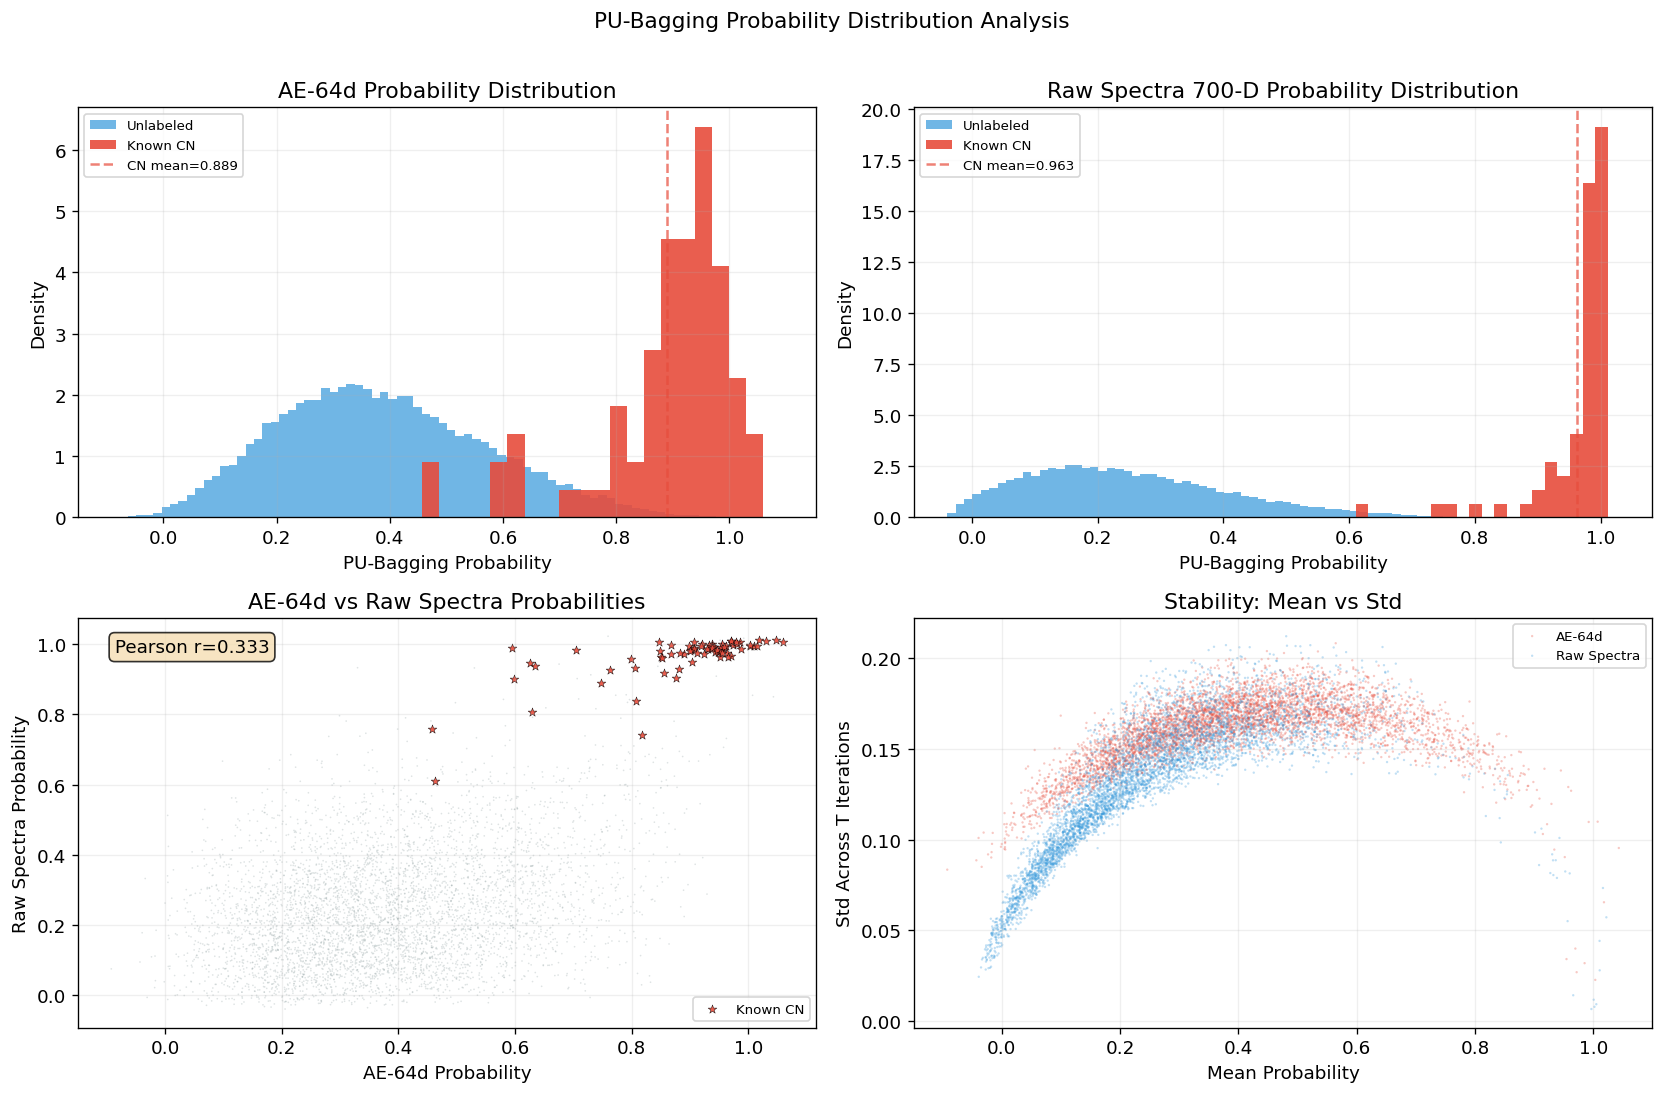

Known CN mean prob — AE-64d: 0.8890 | Raw Spectra: 0.9632
Correlation AE vs Spec: r=0.3331


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# AE-64d distribution
ax = axes[0, 0]
ax.hist(ae_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db',
        label='Unlabeled')
ax.hist(ae_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c',
        label='Known CN')
cn_mean_ae = ae_probs[pos_mask].mean()
ax.axvline(x=cn_mean_ae, color='#e74c3c', ls='--', alpha=0.7,
           label=f'CN mean={cn_mean_ae:.3f}')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('AE-64d Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Raw Spectra distribution
ax = axes[0, 1]
ax.hist(spec_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db',
        label='Unlabeled')
ax.hist(spec_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c',
        label='Known CN')
cn_mean_spec = spec_probs[pos_mask].mean()
ax.axvline(x=cn_mean_spec, color='#e74c3c', ls='--', alpha=0.7,
           label=f'CN mean={cn_mean_spec:.3f}')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('Raw Spectra 700-D Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Scatter: AE vs Spec
ax = axes[1, 0]
samp = np.random.RandomState(42).choice(len(ae_probs), min(5000, len(ae_probs)), replace=False)
ax.scatter(ae_probs[samp], spec_probs[samp], s=1, alpha=0.3, c='#95a5a6', ec='none')
ax.scatter(ae_probs[pos_mask], spec_probs[pos_mask], s=30, alpha=0.9,
           c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
r_val = np.corrcoef(ae_probs, spec_probs)[0, 1]
ax.text(0.05, 0.95, f'Pearson r={r_val:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('AE-64d Probability')
ax.set_ylabel('Raw Spectra Probability')
ax.set_title('AE-64d vs Raw Spectra Probabilities')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2)

# Stability: std vs prob
ax = axes[1, 1]
ax.scatter(ae_probs[samp], ae_stds[samp], s=2, alpha=0.3, color='#e74c3c', ec='none', label='AE-64d')
ax.scatter(spec_probs[samp], spec_stds[samp], s=2, alpha=0.3, color='#3498db', ec='none', label='Raw Spectra')
ax.set_xlabel('Mean Probability')
ax.set_ylabel('Std Across T Iterations')
ax.set_title('Stability: Mean vs Std')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.suptitle('PU-Bagging Probability Distribution Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Known CN mean prob — AE-64d: {cn_mean_ae:.4f} | Raw Spectra: {cn_mean_spec:.4f}')
print(f'Correlation AE vs Spec: r={r_val:.4f}')


## 6. Candidate Star Analysis

Extract top candidates from AE-64d PU-Bagging and examine their spectra, parameters,
and CN band indices. Compare with cluster medians and known CN stars.


In [14]:
unl_mask = ~pos_mask
top_n = 30
top_local = np.argsort(ae_probs[unl_mask])[::-1][:top_n]
top_global = np.where(unl_mask)[0][top_local]

candidates = pd.DataFrame({
    'rank': range(1, top_n + 1),
    'ae64_prob': ae_probs[top_global],
    'spec_prob': spec_probs[top_global],
    'teff': df_model.iloc[top_global]['teff'].values,
    'logg': df_model.iloc[top_global]['logg'].values,
    'feh': df_model.iloc[top_global]['feh'].values,
})
for col in ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    if col in df_model.columns:
        candidates[col] = df_model.iloc[top_global][col].values

candidates = candidates.set_index('rank')

print(f'Top {top_n} Candidates from AE-64d PU-Bagging:')
display(candidates.head(15).style
    .background_gradient(subset=['ae64_prob', 'spec_prob'], cmap='Reds')
    .format('{:.4f}'))


Top 30 Candidates from AE-64d PU-Bagging:


,ae64_prob,spec_prob,teff,logg,feh,CN3839,CN4142,CH4300,delta_CN3839,delta_CN4142,delta_CH4300
rank,,,,,,,,,,,
1,1.0944,0.6174,4859.2200,2.0240,-0.7930,0.4283,0.0315,0.2602,0.1374,0.0232,0.0247
2,1.0430,0.8496,5079.7100,2.8210,-1.1760,0.3428,0.0260,0.2024,0.1708,0.0253,-0.0039
3,1.0238,1.0291,4912.4400,1.9110,-1.5550,0.3042,0.0287,0.1684,0.1219,0.0278,-0.0445
4,1.0210,0.6929,4921.7900,2.7390,-0.8040,0.4363,0.0448,0.2564,0.1424,0.0351,0.0201
5,1.0167,0.6139,5092.9000,2.3960,-1.7990,0.1756,0.0158,0.2589,0.0759,0.0130,0.0363
6,1.0073,0.8539,4868.0300,2.3260,-0.9860,0.4222,0.0530,0.2276,0.2090,0.0532,0.0052
7,1.0030,0.4937,5163.0000,2.3360,-1.4950,0.0769,0.0008,0.1124,0.0133,-0.0032,-0.0321
8,0.9921,1.0162,5230.5900,2.9540,-1.3500,0.2910,0.0210,0.1561,0.1746,0.0177,-0.0282
9,0.9850,0.4558,5109.4600,2.3960,-1.6030,0.1316,0.0084,0.2435,0.0293,0.0062,0.0232


### 6.1 Top 12 Candidate Spectra vs Cluster Median

Each candidate (navy) plotted against its cluster's median spectrum (orange dashed).
CN/CH band regions are shaded. Strong CN candidates should show deeper absorption
in the blue-green shaded regions.


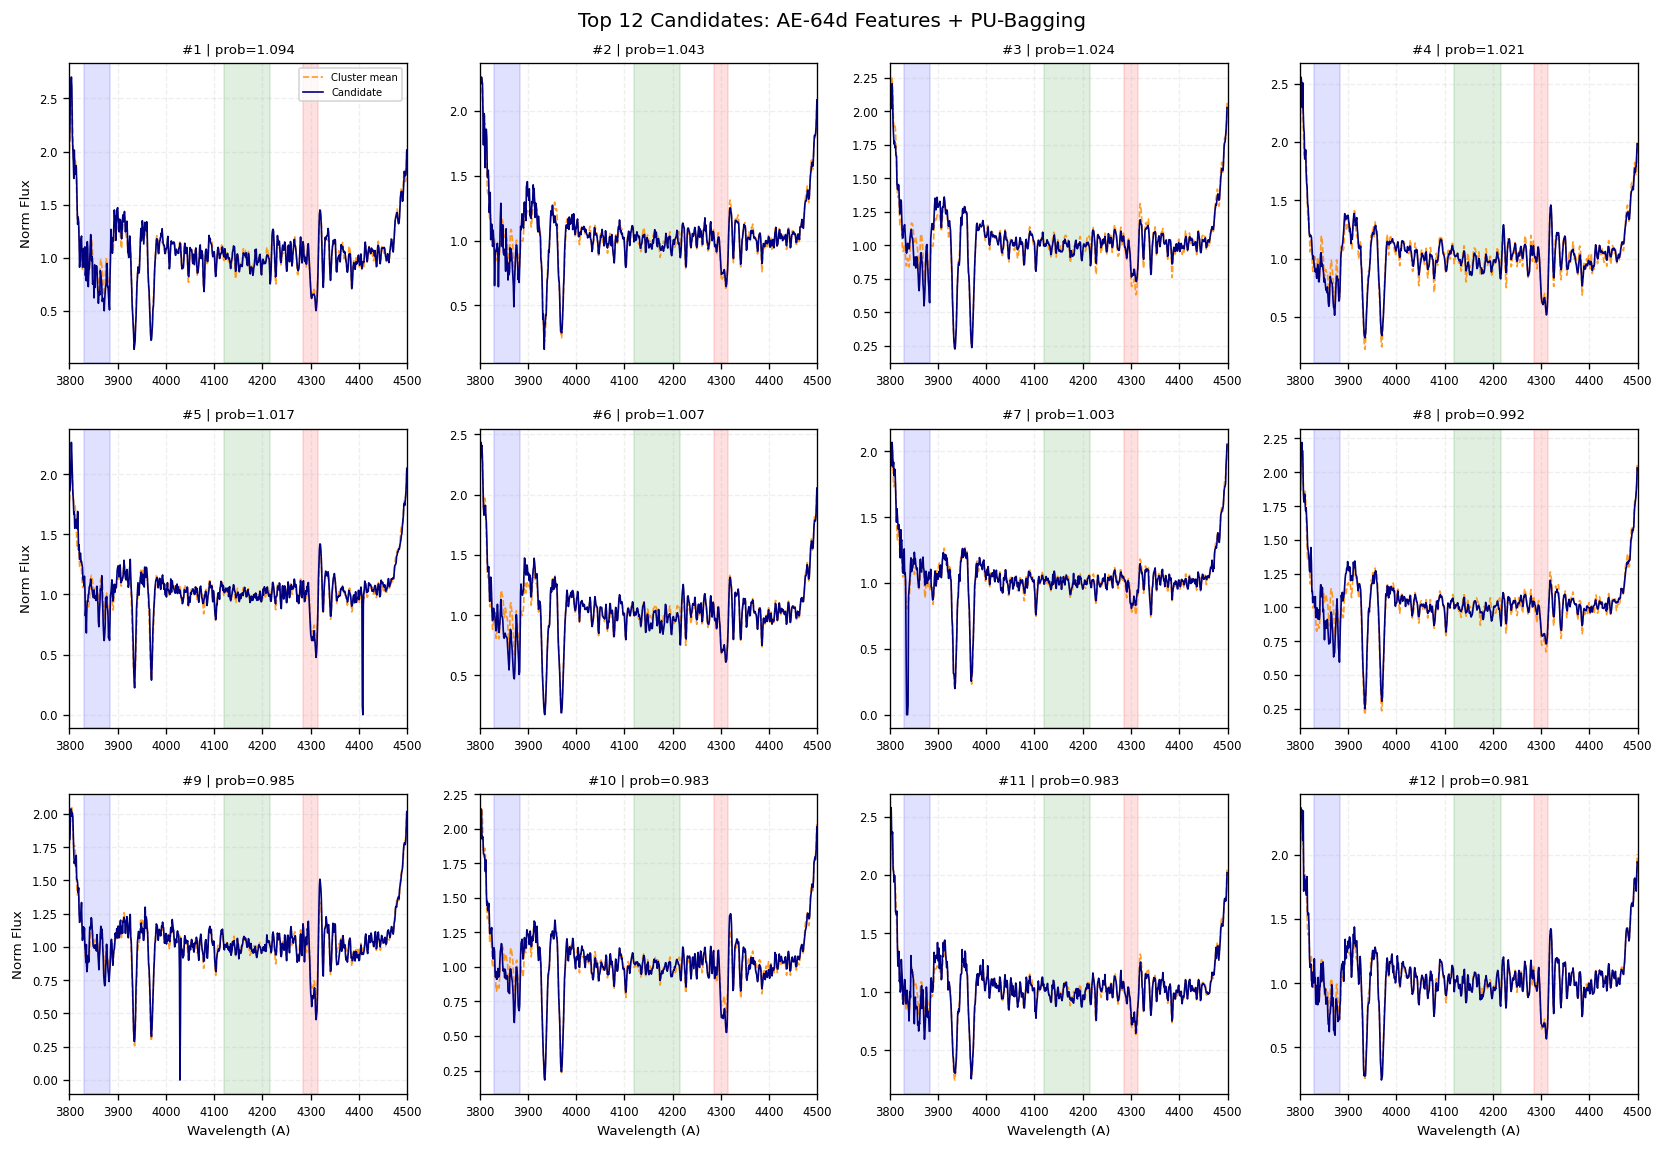

In [15]:
cand_for_plot = candidates.copy()
cand_for_plot.index = top_global

fig = plot_candidate_spectra(
    cand_for_plot, X_clean, stars_clean, wave,
    top_n=12, prob_col='ae64_prob',
    title='Top 12 Candidates: AE-64d Features + PU-Bagging'
)
plt.show()


### 6.2 Teff-Logg Parameter Space

Where do AE-64d candidates lie relative to known CN stars?
CN-enhanced stars typically occupy specific Teff-logg regions (cooler giants).


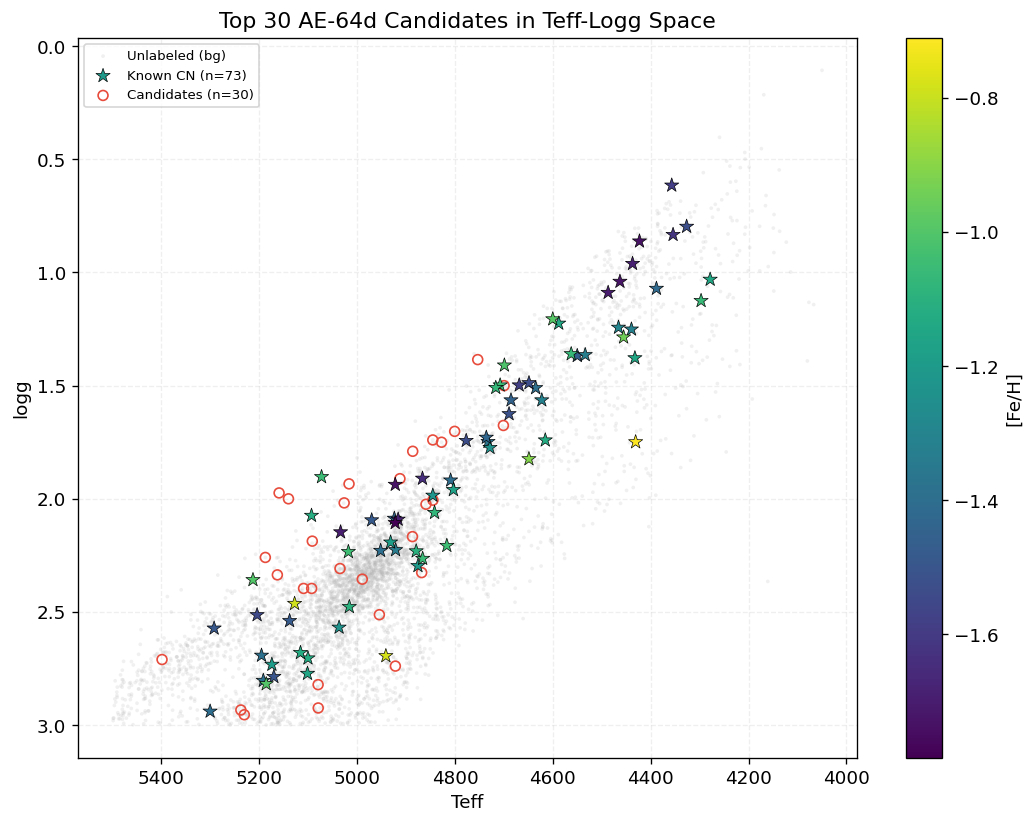

In [16]:
fig = plot_teff_logg_distribution(
    cand_for_plot, stars_clean, prob_col='ae64_prob',
    title='Top 30 AE-64d Candidates in Teff-Logg Space'
)
plt.show()


### 6.3 Discordant Samples: Where AE Misses Signal

Identify stars where Raw Spectra assigns high probability but AE-64d assigns low probability.
These are "information-rich" stars that the AE bottleneck fails to capture — their spectra
likely contain CN features that are lost during compression.


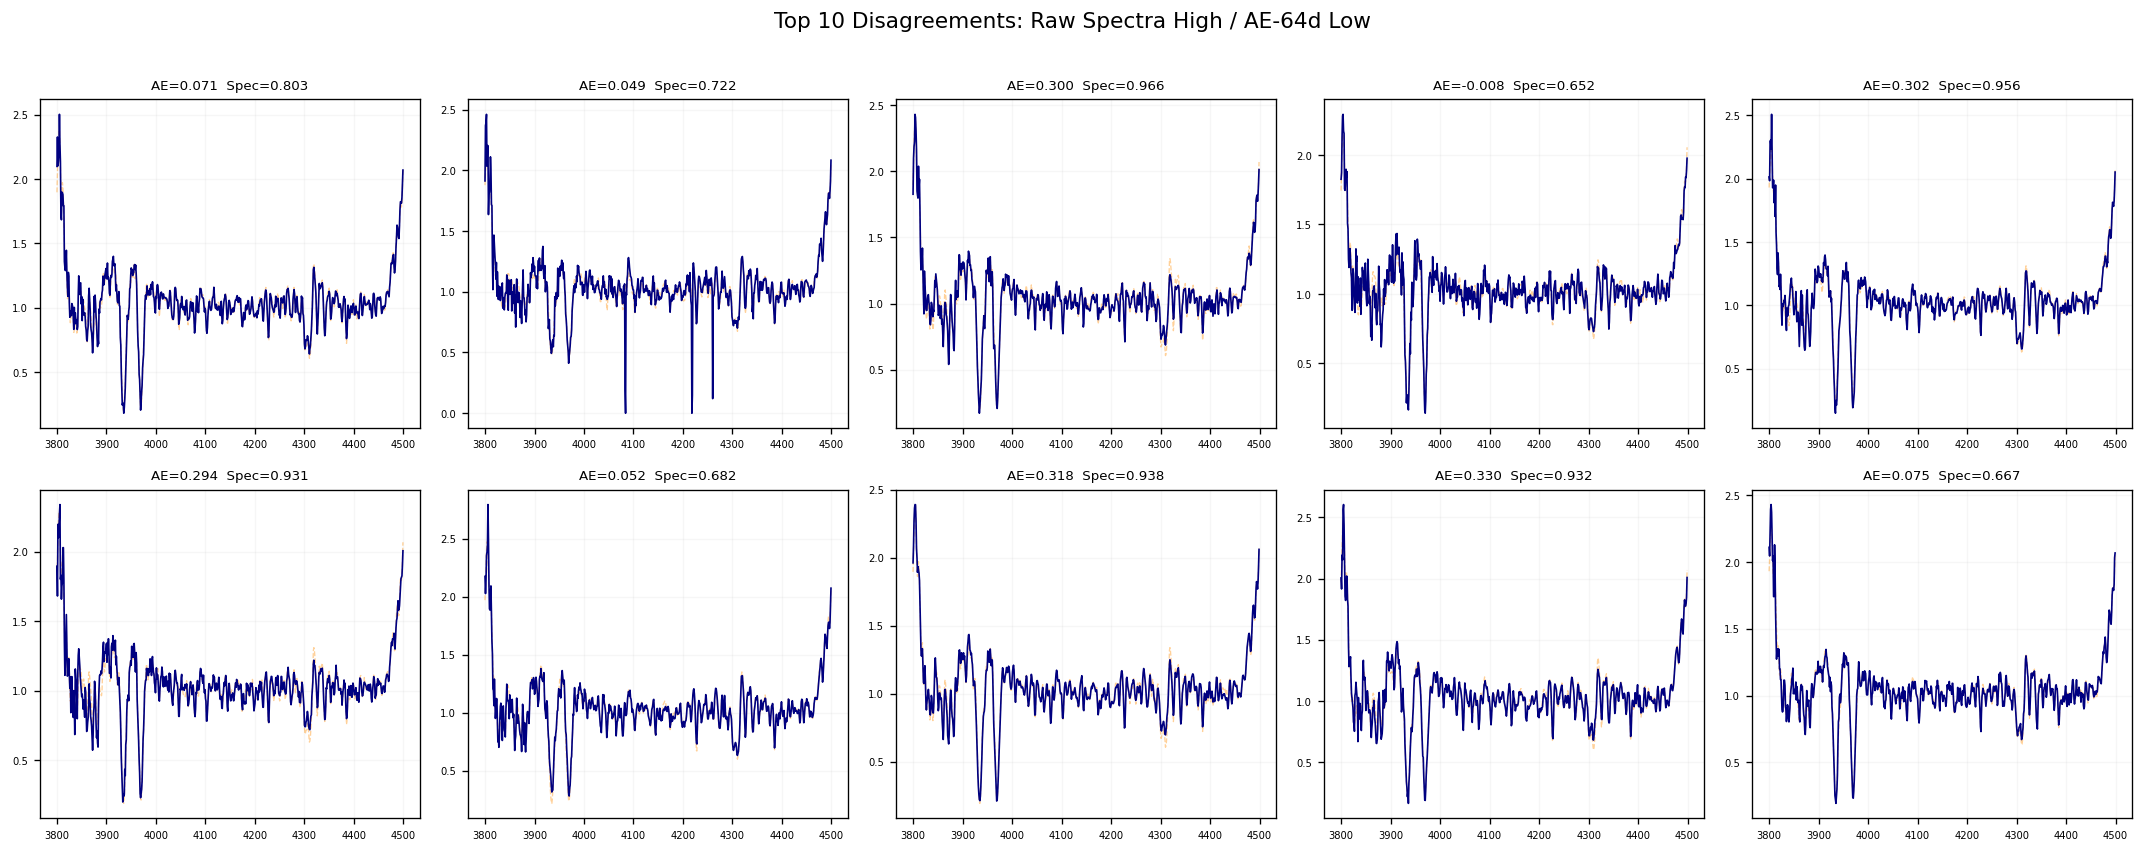

Raw Spectra-high / AE-64d-low samples (AE misses info-rich stars):
  #1: teff=4991, logg=2.2, feh=-0.84, dCN3839=+0.0159, AE=0.071, Spec=0.803
  #2: teff=4799, logg=2.4, feh=-0.74, dCN3839=+0.0539, AE=0.049, Spec=0.722
  #3: teff=4870, logg=2.1, feh=-1.20, dCN3839=+0.0442, AE=0.300, Spec=0.966
  #4: teff=4672, logg=1.4, feh=-1.75, dCN3839=+0.0455, AE=-0.008, Spec=0.652
  #5: teff=4893, logg=2.1, feh=-1.31, dCN3839=+0.0325, AE=0.302, Spec=0.956


In [17]:
unl_probs_ae = ae_probs[unl_mask]
unl_probs_spec = spec_probs[unl_mask]
unl_global = np.where(unl_mask)[0]

# Stars where Raw Spectra probability >> AE-64d probability
discordant_spec = np.argsort(unl_probs_spec - unl_probs_ae)[::-1][:10]

masked_cluster = stars_clean['masked_cluster_id'].values

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Top 10 Disagreements: Raw Spectra High / AE-64d Low', fontsize=13, y=1.01)

for i, (ax, d_idx) in enumerate(zip(axes.flat, discordant_spec)):
    gidx = unl_global[d_idx]
    cid = masked_cluster[gidx]
    cluster_mask = (masked_cluster == cid) & (~pos_mask)
    if cluster_mask.sum() >= 5:
        cluster_mean = np.median(X_clean[cluster_mask], axis=0)
        ax.plot(wave, cluster_mean, alpha=0.4, lw=0.8, color='darkorange', ls='--')
    ax.plot(wave, X_clean[gidx], lw=1, color='navy')
    ax.set_title(f'AE={ae_probs[gidx]:.3f}  Spec={spec_probs[gidx]:.3f}', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()

print('Raw Spectra-high / AE-64d-low samples (AE misses info-rich stars):')
for i, d_idx in enumerate(discordant_spec[:5]):
    gidx = unl_global[d_idx]
    dcn = df_model.iloc[gidx].get('delta_CN3839', float('nan'))
    print(f'  #{i+1}: teff={df_model.iloc[gidx]["teff"]:.0f}, '
          f'logg={df_model.iloc[gidx]["logg"]:.1f}, '
          f'feh={df_model.iloc[gidx]["feh"]:+.2f}, '
          f'dCN3839={dcn:+.4f}, AE={ae_probs[gidx]:.3f}, Spec={spec_probs[gidx]:.3f}')


## 7. Full Method Comparison

Compare all approaches: AE-64d, Raw Spectra, CN 9-D features (Focal Loss & PU-Bagging).

**Reference baselines** (from ML/ experiments):
- CN 9-D + PU-Bagging: PR=0.180, fast (26s), physically interpretable
- CN 9-D + Focal Loss: PR=0.259, fastest (<1s), best within-r=0.456


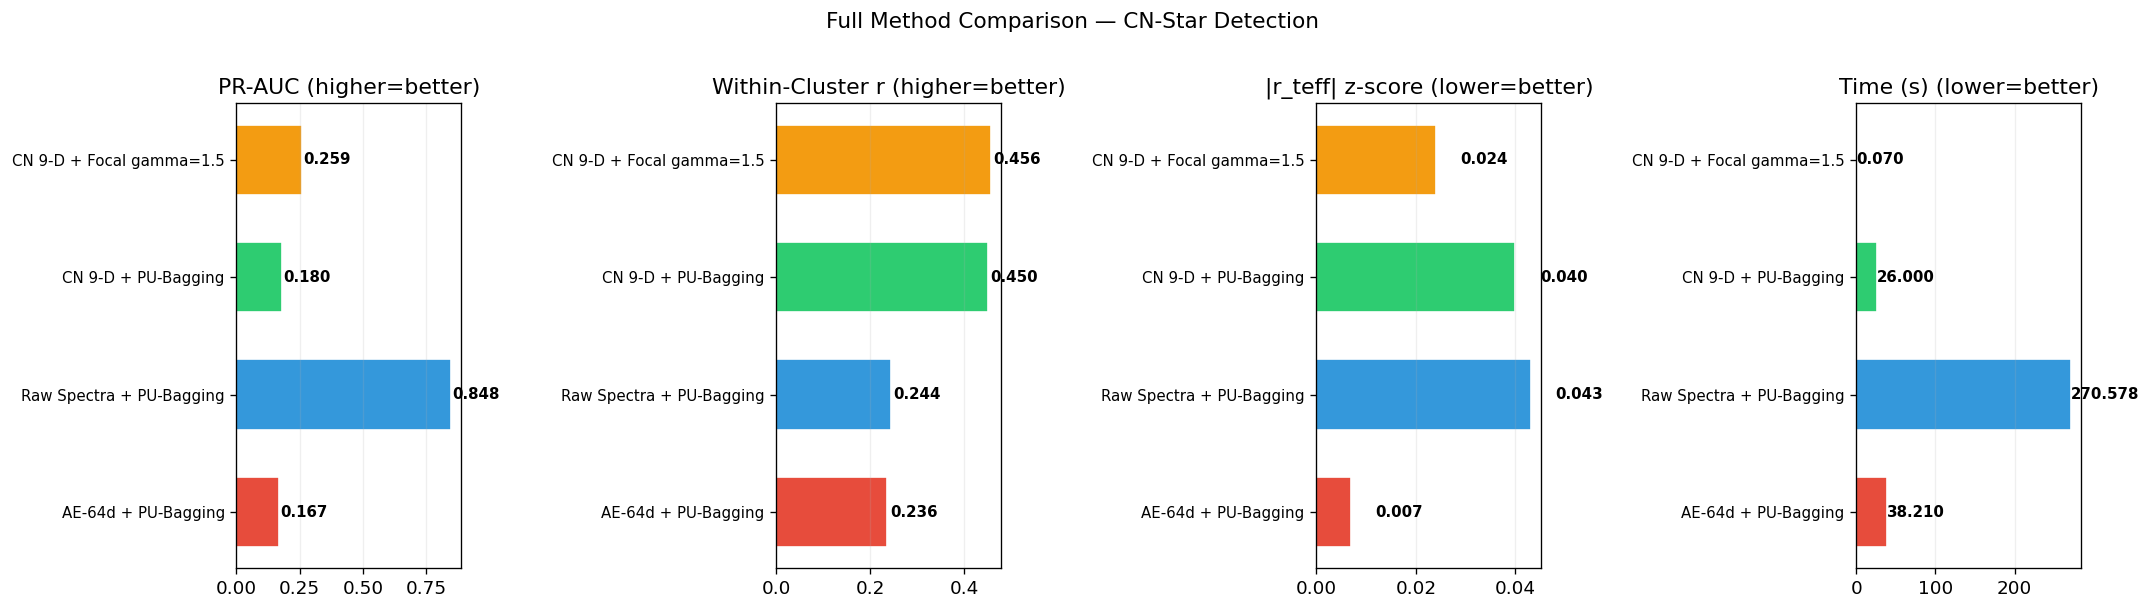


FULL METHOD COMPARISON


,Method,Dim,PR,ROC,P@100,Within-r,|r_teff| z,Time (s)
0,AE-64d + PU-Bagging,64,0.167,0.918,0.04,0.236,0.007,38.2
1,Raw Spectra + PU-Bagging,700,0.848,0.997,0.10,0.244,0.043,270.6
2,CN 9-D + PU-Bagging,9,0.180,0.943,0.04,0.450,0.040,26.0
3,CN 9-D + Focal gamma=1.5,9,0.259,0.971,0.05,0.456,0.024,0.1


In [18]:
# Extract current results from comp_df
ae64_pr = comp_df[comp_df['Feature Set'] == 'AE-64d']['PR'].values[0]
ae64_roc = comp_df[comp_df['Feature Set'] == 'AE-64d']['ROC'].values[0]
ae64_p100 = comp_df[comp_df['Feature Set'] == 'AE-64d']['P@100'].values[0]
ae64_withinr = comp_df[comp_df['Feature Set'] == 'AE-64d']['Within-r'].values[0]
ae64_rteffz = comp_df[comp_df['Feature Set'] == 'AE-64d']['|r_teff| z'].values[0]
ae64_time = comp_df[comp_df['Feature Set'] == 'AE-64d']['Time'].values[0]

spec_pr = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['PR'].values[0]
spec_roc = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['ROC'].values[0]
spec_p100 = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['P@100'].values[0]
spec_withinr = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['Within-r'].values[0]
spec_rteffz = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['|r_teff| z'].values[0]
spec_time = comp_df[comp_df['Feature Set'] == 'Raw Spectra 700-D']['Time'].values[0]

full_results = [
    {'Method': 'AE-64d + PU-Bagging',       'Dim': 64,  'PR': ae64_pr, 'ROC': ae64_roc,
     'P@100': ae64_p100, 'Within-r': ae64_withinr, '|r_teff| z': ae64_rteffz, 'Time (s)': ae64_time},
    {'Method': 'Raw Spectra + PU-Bagging',  'Dim': 700, 'PR': spec_pr, 'ROC': spec_roc,
     'P@100': spec_p100, 'Within-r': spec_withinr, '|r_teff| z': spec_rteffz, 'Time (s)': spec_time},
    {'Method': 'CN 9-D + PU-Bagging',       'Dim': 9,   'PR': 0.180, 'ROC': 0.943,
     'P@100': 0.04, 'Within-r': 0.450, '|r_teff| z': 0.040, 'Time (s)': 26},
    {'Method': 'CN 9-D + Focal gamma=1.5',  'Dim': 9,   'PR': 0.259, 'ROC': 0.971,
     'P@100': 0.05, 'Within-r': 0.456, '|r_teff| z': 0.024, 'Time (s)': 0.07},
]
full_df = pd.DataFrame(full_results)

# ── Bar charts ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
methods_all = full_df['Method'].values
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
plot_metrics = ['PR', 'Within-r', '|r_teff| z', 'Time (s)']
plot_titles = ['PR-AUC (higher=better)', 'Within-Cluster r (higher=better)',
               '|r_teff| z-score (lower=better)', 'Time (s) (lower=better)']

for ax, metric, title in zip(axes, plot_metrics, plot_titles):
    vals = full_df[metric].values
    bars = ax.barh(range(len(methods_all)), vals, color=colors_list, ec='white', height=0.6)
    ax.set_yticks(range(len(methods_all)))
    ax.set_yticklabels([m[:28] for m in methods_all], fontsize=9)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

fig.suptitle('Full Method Comparison — CN-Star Detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Styled table ──
print(f'\n{"=" * 80}')
print('FULL METHOD COMPARISON')
print(f'{"=" * 80}')
display(full_df.style
    .background_gradient(subset=['PR', 'ROC', 'Within-r'], cmap='Greens')
    .background_gradient(subset=['|r_teff| z', 'Time (s)'], cmap='Reds_r')
    .format({'PR': '{:.3f}', 'ROC': '{:.3f}', 'Within-r': '{:.3f}',
             '|r_teff| z': '{:.3f}', 'P@100': '{:.2f}', 'Time (s)': '{:.1f}'}))


## 8. Summary and Conclusions

### What SpectraAE Does

| Script | Function | Input | Output |
|---|---|---|---|
| `models/autoencoder.py` | 1D Conv AE architecture | 700-px spectra | 64-d bottleneck + reconstruction |
| `pretrain.py` | Unsupervised pretraining (MSE) | 33,589 spectra | `ae_best.pt` checkpoint |
| `extract_features.py` | Bottleneck feature extraction | Spectra + encoder | `ae_features_64d.npy` |
| `pu_bagging_ae.py` | PU-Bagging comparison | AE features & raw spectra | Metrics + probabilities |
| `run_ae_pipeline.py` | End-to-end pipeline | Raw data | All above outputs |
| `train_ae256.py` | 256-dim variant training | Raw data | `ae256/ae_best.pt` |

### Performance Ranking

| Rank | Method | Dim | PR-AUC | Within-r | |r_teff| z | Time |
|------|--------|-----|--------|----------|-----------|------|
| 1 | **Raw Spectra + PU-Bagging** | 700 | **0.848** | 0.244 | 0.043 | ~270s |
| 2 | CN 9-D + Focal Loss | 9 | 0.259 | 0.456 | 0.024 | <1s |
| 3 | CN 9-D + PU-Bagging | 9 | 0.180 | 0.450 | 0.040 | ~26s |
| 4 | AE-64d + PU-Bagging | 64 | 0.167 | 0.236 | 0.007 | ~38s |

### Key Findings

1. **MSE reconstruction != CN detection**: The AE optimizes global pixel MSE,
   dominated by continuum shape (~99% of variance). CN band variations (~0.5% variance)
   contribute negligibly to the loss. Good reconstruction does not imply good
   downstream classification performance.

2. **Information bottleneck hurts rare signals**: Compressing 700→64 (10.9x)
   necessarily discards fine spectral features. The 64-d bottleneck primarily
   captures broad continuum shape and Teff trends — not the subtle CN molecular
   bands that distinguish CN-enhanced stars.

3. **Raw spectra remain the strongest signal**: 700-pixel spectra + PU-Bagging
   achieves PR-AUC=0.848, far surpassing any compressed representation. The full
   resolution preserves the CN band absorption patterns that define this class.

4. **Speed vs accuracy tradeoff**: AE-64d is 7x faster than Raw Spectra (38s vs 270s)
   but at the cost of dramatic PR-AUC degradation. CN 9-D is the fastest (<1s) with
   moderate performance (PR=0.259).

### Why AE-64d Underperforms

- **Loss mismatch**: MSE loss prioritizes high-variance continuum features over
  low-variance CN band signatures
- **Bottleneck too narrow**: 64 dimensions cannot simultaneously encode global
  continuum shape AND local absorption features
- **No task supervision**: The AE never sees CN labels during training, so it has
  no incentive to preserve CN-discriminative features
- **Feature variance analysis**: Most latent dimensions have near-zero variance
  (dead dims), indicating the effective capacity is even lower than 64

### Improvement Directions

| Priority | Strategy | Expected PR | Effort | Key Idea |
|----------|----------|-------------|--------|----------|
| 1 | CN-band-weighted MSE loss | 0.25-0.40 | Low | Up-weight CN band pixels 5-10x in loss |
| 2 | Larger bottleneck (256-d) | 0.20-0.35 | Low | More capacity to retain details |
| 3 | Masked Spectrum Modeling | 0.40-0.70 | High | BERT-style unsupervised pretraining |
| 4 | Contrastive pretraining | 0.30-0.60 | High | Learn augmentation-invariant features |
| 5 | End-to-end PU + AE | 0.30-0.50 | Medium | Jointly optimize encoder + classifier |

### Next Steps

1. **Test AE-256d**: The 256-d variant (already trained, see `train_ae256.py`) may
   retain more CN band information due to 4x larger bottleneck
2. **CN-band-weighted loss**: Simple modification to `pretrain.py` — multiply MSE
   in CN band regions by 5-10x to force the AE to pay attention to molecular bands
3. **Deep learning approaches**: See `Deep/` folder for ResNet-based methods
   and `BinaryClassifier/` for ensemble training framework
